# 🌊 Sistem Rekomendasi Pantai Tersehat - Pesisir Banten

Notebook ini berisi implementasi **Sistem Rekomendasi Pantai Tersehat** di pesisir Provinsi Banten. 
Sistem rekomendasi ini didasarkan pada **Multi-Criteria Decision Analysis (MCDA)** yang menggabungkan beberapa indikator kualitas air dari citra satelit **Sentinel-2** serta pengaruh lingkungan darat (aktivitas industri terdekat).

---

## 📋 Metodologi & Pembobotan Parameter

Health Score (0-100) dihitung untuk masing-masing pantai dengan bobot komposit berikut:

| Parameter | Bobot | Deskripsi | Logika Normalisasi |
|---|---|---|---|
| **Persentase Area Sehat** (`Pct_Sehat_2026`) | **30%** | Persentase area air laut dengan kondisi sehat/optimal. | Semakin tinggi = semakin baik |
| **Indeks Kekeruhan** (`Mean_NDTI_2026`) | **20%** | Tingkat kekeruhan air akibat sedimentasi. | Semakin rendah = semakin baik (Inverted) |
| **Indeks Klorofil-a** (`Mean_NDCI_2026`) | **10%** | Konsentrasi klorofil-a (indikator blooming alga/eutrofikasi). | Semakin rendah = semakin baik (Inverted) |
| **TSS Proxy** (`Mean_TSS_2026`) | **10%** | Padatan tersuspensi total di perairan. | Semakin rendah = semakin baik (Inverted) |
| **CDOM Proxy** (`Mean_CDOM_2026`) | **5%** | Bahan organik terlarut berwarna. | Semakin rendah = semakin baik (Inverted) |
| **Tren Kualitas Historis** | **15%** | Perkembangan kualitas air dibandingkan baseline 2017. | `MEMBAIK` (skor 100) > `STABIL` (skor 50) > `MEMBURUK` (skor 0) |
| **Dampak Industri Terdekat** | **10%** | Potensi polusi dari industri berdasarkan jarak terdekat. | `RENDAH` (skor 100) > `SEDANG` (skor 50) > `TINGGI` (skor 0) |

---

## 1. Setup Lingkungan & Import Library

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium import plugins

# Mengarahkan ke folder output
OUTPUT_DIR = "output"
BEACH_DATA_PATH = os.path.join(OUTPUT_DIR, "banten_water_quality_beach.json")

if not os.path.exists(BEACH_DATA_PATH):
    print(f"WARNING: File data pantai tidak ditemukan di {BEACH_DATA_PATH}.")
    print("Pastikan Anda telah menjalankan analisis utama di notebook Aquality-Model.ipynb terlebih dahulu.")
else:
    print("Setup berhasil! File data pantai terdeteksi.")

Setup berhasil! File data pantai terdeteksi.


## 2. Memuat Data Kualitas Air Pantai Banten

In [2]:
with open(BEACH_DATA_PATH, "r", encoding="utf-8") as f:
    beach_data = json.load(f)

# Konversi JSON ke Pandas DataFrame untuk kemudahan manipulasi
df_beaches = pd.DataFrame.from_dict(beach_data, orient="index").reset_index().rename(columns={"index": "Pantai"})
print(f"Berhasil memuat {len(df_beaches)} pantai pesisir Banten.")
df_beaches.head(5)

Berhasil memuat 25 pantai pesisir Banten.


,Pantai,Kecamatan,Kabupaten_Kota,url_gambar,latitude,longitude,Luas_Air_2026_Ha,Sehat_2026_Ha,Sedang_2026_Ha,TidakSehat_2026_Ha,...,jarak_industri_3_km,Luas_Air_2017_Ha,Sehat_2017_Ha,Pct_Sehat_2017,Mean_NDTI_2017,Mean_NDCI_2017,Status_Kualitas_2017,Delta_Pct_Sehat,Tren_Kualitas,penjelasan_kualitas
0,Pantai Anyer,Anyar,Serang,https://kabarfaktual.com/libur-lebaran-2024-pa...,-6.0465,105.8850,323.91,20.88,4.05,298.98,...,13.59,329.58,63.63,19.3,0.0848,0.0516,TIDAK SEHAT,-12.9,MEMBURUK,Kualitas air di Pantai Anyer (Anyar) tergolong...
1,Pantai Carita,Carita,Pandeglang,https://id.wikipedia.org/wiki/Pantai_Carita,-6.1305,105.8427,328.77,0.99,0.00,327.78,...,21.17,326.43,17.91,5.5,0.1276,0.0445,TIDAK SEHAT,-5.2,MEMBURUK,Kualitas air di Pantai Carita (Carita) tergolo...
2,Pantai Tanjung Lesung,Panimbang,Pandeglang,https://santanarentalmobilsolo.com/pantai-tanj...,-6.4785,105.6565,202.86,3.87,0.00,198.99,...,59.69,208.62,32.49,15.6,0.0789,0.0641,TIDAK SEHAT,-13.7,MEMBURUK,Kualitas air di Pantai Tanjung Lesung (Panimba...
3,Pantai Sawarna,Bayah,Lebak,https://id.pinterest.com/pin/764697211775211464/,-6.9930,106.3180,185.67,1.80,1.17,182.70,...,108.21,184.14,2.25,1.2,0.1343,0.0091,TIDAK SEHAT,-0.2,STABIL,Kualitas air di Pantai Sawarna (Bayah) tergolo...
4,Pantai Bagedur,Malingping,Lebak,https://jendelapuspita.com/pantai-bagedur-leba...,-6.9038,106.0125,330.93,0.00,0.00,330.93,...,95.58,327.96,196.65,60.0,0.0440,0.0233,SEHAT,-60.0,MEMBURUK,Kualitas air di Pantai Bagedur (Malingping) te...


## 3. Kalkulasi Health Score Komposit (Model Rekomendasi)

In [3]:
# 1. Definisi Parameter Bobot dan Skoring
WEIGHTS = {
    "pct_sehat": 0.30,
    "ndti_inv": 0.20,
    "ndci_inv": 0.10,
    "tss_inv": 0.10,
    "cdom_inv": 0.05,
    "tren": 0.15,
    "industri_inv": 0.10,
}

TREN_SCORES = {"MEMBAIK": 1.0, "STABIL": 0.5, "MEMBURUK": 0.0}
INDUSTRI_SCORES = {"RENDAH": 1.0, "SEDANG": 0.5, "TINGGI": 0.0}

HEALTH_LABELS = [
    (80, "SANGAT DIREKOMENDASIKAN"),
    (60, "DIREKOMENDASIKAN"),
    (40, "CUKUP DIREKOMENDASIKAN"),
    (20, "KURANG DIREKOMENDASIKAN"),
    (0, "TIDAK DIREKOMENDASIKAN"),
]

def get_recommendation_label(score):
    for threshold, label in HEALTH_LABELS:
        if score >= threshold:
            return label
    return "TIDAK DIREKOMENDASIKAN"

# 2. Kumpulkan nilai ekstrem untuk normalisasi Min-Max
pct_vals = df_beaches["Pct_Sehat_2026"].values
ndti_vals = df_beaches["Mean_NDTI_2026"].abs().values
ndci_vals = df_beaches["Mean_NDCI_2026"].abs().values
tss_vals = df_beaches["Mean_TSS_2026"].values
cdom_vals = df_beaches["Mean_CDOM_2026"].values

min_pct, max_pct = pct_vals.min(), pct_vals.max()
min_ndti, max_ndti = ndti_vals.min(), ndti_vals.max()
min_ndci, max_ndci = ndci_vals.min(), ndci_vals.max()
min_tss, max_tss = tss_vals.min(), tss_vals.max()
min_cdom, max_cdom = cdom_vals.min(), cdom_vals.max()

def normalize(val, min_v, max_v, invert=False):
    if max_v == min_v:
        return 50.0
    norm = (val - min_v) / (max_v - min_v)
    if invert:
        norm = 1.0 - norm
    return max(0.0, min(100.0, norm * 100.0))

# 3. Iterasi kalkulasi komposit
health_scores = []
recommendation_labels = []

for idx, row in df_beaches.iterrows():
    s_pct = normalize(row["Pct_Sehat_2026"], min_pct, max_pct)
    s_ndti = normalize(abs(row["Mean_NDTI_2026"]), min_ndti, max_ndti, invert=True)
    s_ndci = normalize(abs(row["Mean_NDCI_2026"]), min_ndci, max_ndci, invert=True)
    s_tss = normalize(row["Mean_TSS_2026"], min_tss, max_tss, invert=True)
    s_cdom = normalize(row["Mean_CDOM_2026"], min_cdom, max_cdom, invert=True)
    s_tren = TREN_SCORES.get(row["Tren_Kualitas"], 0.5) * 100.0
    s_industri = INDUSTRI_SCORES.get(row["kategori_dampak_industri"], 0.5) * 100.0
    
    score = (
        WEIGHTS["pct_sehat"] * s_pct +
        WEIGHTS["ndti_inv"] * s_ndti +
        WEIGHTS["ndci_inv"] * s_ndci +
        WEIGHTS["tss_inv"] * s_tss +
        WEIGHTS["cdom_inv"] * s_cdom +
        WEIGHTS["tren"] * s_tren +
        WEIGHTS["industri_inv"] * s_industri
    )
    score = round(score, 2)
    health_scores.append(score)
    recommendation_labels.append(get_recommendation_label(score))

df_beaches["Health_Score"] = health_scores
df_beaches["Label_Rekomendasi"] = recommendation_labels

# Urutkan berdasarkan Health Score tertinggi
df_beaches = df_beaches.sort_values(by="Health_Score", ascending=False).reset_index(drop=True)
df_beaches["Ranking"] = df_beaches.index + 1

print("Perhitungan selesai! Menampilkan 10 Pantai Teratas:")
df_beaches[["Ranking", "Pantai", "Kecamatan", "Kabupaten_Kota", "Health_Score", "Label_Rekomendasi"]].head(10)

Perhitungan selesai! Menampilkan 10 Pantai Teratas:


,Ranking,Pantai,Kecamatan,Kabupaten_Kota,Health_Score,Label_Rekomendasi
0,1,Pantai Tanjung Pasir,Teluknaga,Tangerang,84.24,SANGAT DIREKOMENDASIKAN
1,2,Pantai Pulau Cangkir,Kronjo,Tangerang,80.13,SANGAT DIREKOMENDASIKAN
2,3,Pantai Lontar,Tirtayasa,Serang,60.00,DIREKOMENDASIKAN
3,4,Pantai Karang Bolong,Cinangka,Serang,57.59,CUKUP DIREKOMENDASIKAN
4,5,Pantai Sambolo,Anyar,Serang,53.75,CUKUP DIREKOMENDASIKAN
5,6,Pantai Tanjung Kait,Mauk,Tangerang,49.37,CUKUP DIREKOMENDASIKAN
6,7,Pantai Jambu,Cinangka,Serang,48.97,CUKUP DIREKOMENDASIKAN
7,8,Pantai Florida Indah,Cinangka,Serang,48.05,CUKUP DIREKOMENDASIKAN
8,9,Pantai Pasir Putih Cihara,Cihara,Lebak,47.52,CUKUP DIREKOMENDASIKAN
9,10,Pantai Marbella,Anyar,Serang,47.02,CUKUP DIREKOMENDASIKAN


## 4. Analisis & Visualisasi Grafik Rekomendasi

C:\Users\SKYL15H\AppData\Local\Temp\ipykernel_10604\715825064.py:20: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\SKYL15H\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


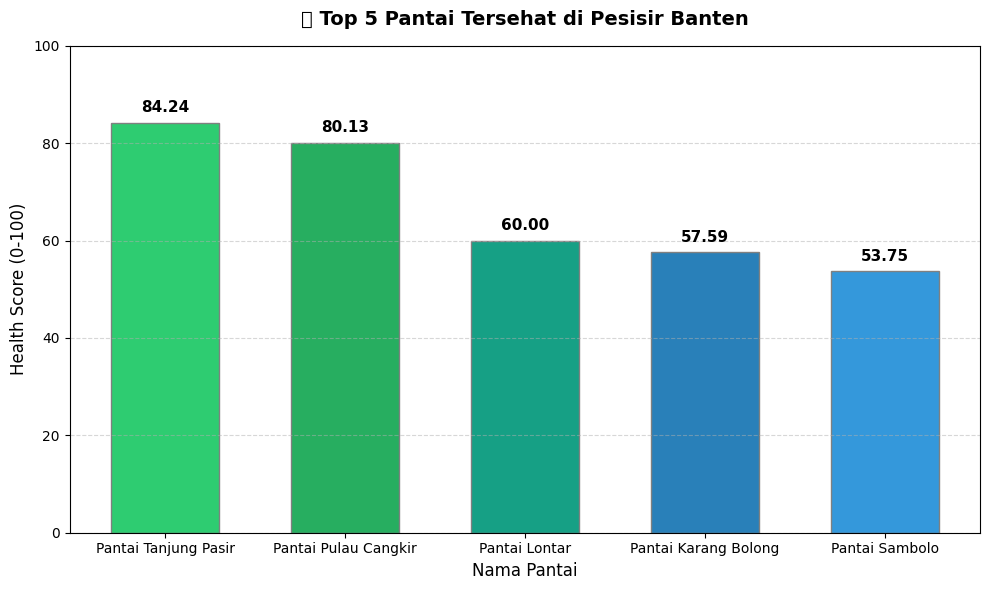

C:\Users\SKYL15H\AppData\Local\Temp\ipykernel_10604\715825064.py:38: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\SKYL15H\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


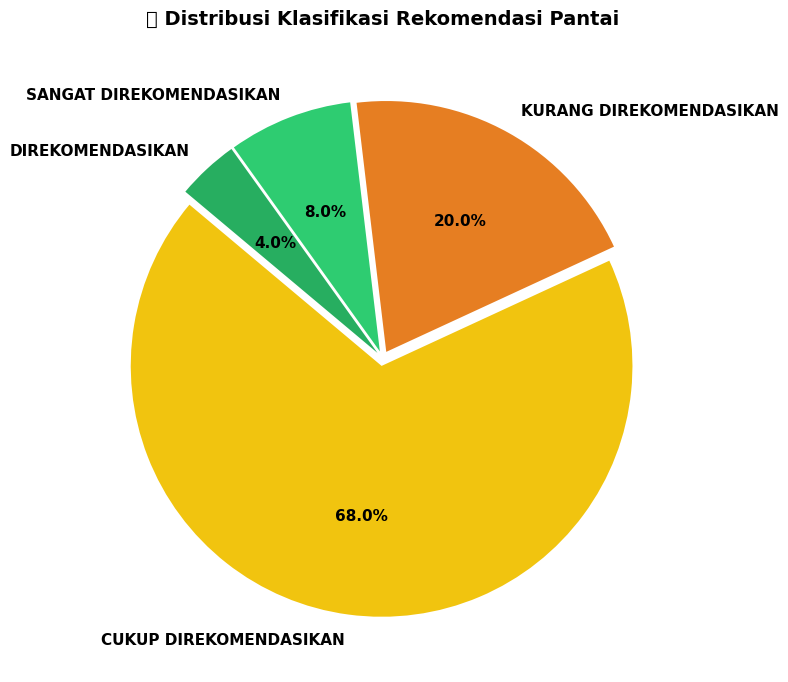

In [4]:
# 1. Bar Chart Top 5 Pantai Tersehat
plt.figure(figsize=(10, 6))
top5 = df_beaches.head(5)
colors = ['#2ecc71', '#27ae60', '#16a085', '#2980b9', '#3498db']

bars = plt.bar(top5["Pantai"], top5["Health_Score"], color=colors, edgecolor='grey', width=0.6)
plt.title("🏆 Top 5 Pantai Tersehat di Pesisir Banten", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Health Score (0-100)", fontsize=12)
plt.xlabel("Nama Pantai", fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menambahkan nilai di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1.5,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Pie Chart Distribusi Label Rekomendasi
plt.figure(figsize=(8, 8))
dist = df_beaches["Label_Rekomendasi"].value_counts()
colors_map = {
    "SANGAT DIREKOMENDASIKAN": "#2ecc71",
    "DIREKOMENDASIKAN": "#27ae60",
    "CUKUP DIREKOMENDASIKAN": "#f1c40f",
    "KURANG DIREKOMENDASIKAN": "#e67e22",
    "TIDAK DIREKOMENDASIKAN": "#e74c3c"
}
pie_colors = [colors_map.get(lbl, "#7f8c8d") for lbl in dist.index]

plt.pie(dist.values, labels=dist.index, autopct='%1.1f%%', startangle=140, 
        colors=pie_colors, textprops={'fontsize': 11, 'weight': 'bold'}, explode=[0.03]*len(dist))
plt.title("📊 Distribusi Klasifikasi Rekomendasi Pantai", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 5. Pemetaan Spasial Rekomendasi Pantai (Interactive Map)

In [5]:
# Memetakan pantai menggunakan Folium dengan ranking & Health Score
centroid_lat = df_beaches["latitude"].mean()
centroid_lon = df_beaches["longitude"].mean()

m = folium.Map(location=[centroid_lat, centroid_lon], zoom_start=10, tiles="cartodbpositron")
plugins.Fullscreen(position="topright", title="Fullscreen", title_cancel="Exit").add_to(m)

color_map = {
    "SANGAT DIREKOMENDASIKAN": "#2ecc71",
    "DIREKOMENDASIKAN": "#27ae60",
    "CUKUP DIREKOMENDASIKAN": "#f1c40f",
    "KURANG DIREKOMENDASIKAN": "#e67e22",
    "TIDAK DIREKOMENDASIKAN": "#e74c3c"
}

for idx, row in df_beaches.iterrows():
    status = row["Status_Kualitas_2026"]
    rec_label = row["Label_Rekomendasi"]
    score = row["Health_Score"]
    ranking = row["Ranking"]
    color = color_map.get(rec_label, "#7f8c8d")
    
    popup_html = f"""
    <div style='font-family: Arial, sans-serif; font-size: 13px; width: 320px; padding: 5px;'>
        <h4 style='margin: 0 0 5px 0; color: #2c3e50;'>#{ranking} - {row['Pantai']}</h4>
        <span style='font-size: 11px; color: #7f8c8d;'>Kecamatan {row['Kecamatan']}, {row['Kabupaten_Kota']}</span>
        <hr style='margin: 8px 0;'/>
        
        <div style='font-size: 14px; margin-bottom: 8px;'>
            <b>Health Score:</b> 
            <span style='color: #2980b9; font-weight: bold;'>{score}/100</span>
        </div>
        
        <div style='font-size: 12px; margin-bottom: 8px;'>
            <b>Rekomendasi:</b> 
            <span style='color: {color}; font-weight: bold;'>{rec_label}</span>
        </div>
        
        <hr style='margin: 8px 0;'/>
        <b>Status Fisik Air:</b> {status} ({row['Pct_Sehat_2026']:.1f}% sehat)<br/>
        <b>Tren Kualitas:</b> {row['Tren_Kualitas']}<br/>
        <b>Industri Terdekat:</b> {row['industri_terdekat']} ({row['jarak_industri_km']:.2f} km)<br/>
        <span style='font-size: 11px; color: #7f8c8d;'>Kategori Dampak Industri: {row['kategori_dampak_industri']}</span>
        <hr style='margin: 8px 0;'/>
        
        <table style='width: 100%; font-size: 11px;'>
            <tr style='background: #f8f9fa;'>
                <td>Mean NDTI (Turbidity):</td>
                <td style='text-align: right;'>{row['Mean_NDTI_2026']:.4f}</td>
            </tr>
            <tr>
                <td>Mean NDCI (Chlorophyll):</td>
                <td style='text-align: right;'>{row['Mean_NDCI_2026']:.4f}</td>
            </tr>
            <tr style='background: #f8f9fa;'>
                <td>Mean TSS Proxy:</td>
                <td style='text-align: right;'>{row['Mean_TSS_2026']:.4f}</td>
            </tr>
        </table>
    </div>
    """
    
    marker_color = "green" if score >= 80 else "darkgreen" if score >= 60 else "orange" if score >= 40 else "red"
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        icon=folium.Icon(color=marker_color, icon="info-sign"),
        tooltip=f"#{ranking} - {row['Pantai']} (Score: {score})",
        popup=folium.Popup(popup_html, max_width=340)
    ).add_to(m)

# Tampilkan Peta
m

## 6. Generator Narasi Penjelasan Rekomendasi Pantai

In [6]:
def get_beach_recommendation_narration(beach_name, df=df_beaches):
    matched = df[df["Pantai"].str.lower() == beach_name.lower()]
    if matched.empty:
        print(f"Pantai '{beach_name}' tidak ditemukan.")
        return
    
    row = matched.iloc[0]
    name = row["Pantai"]
    kec = row["Kecamatan"]
    score = row["Health_Score"]
    label = row["Label_Rekomendasi"]
    ranking = row["Ranking"]
    total = len(df)
    pct = row["Pct_Sehat_2026"]
    tren = row["Tren_Kualitas"]
    industri = row["industri_terdekat"]
    jarak = row["jarak_industri_km"]
    dampak_ind = row["kategori_dampak_industri"]

    narration = f"=== 🏝️ ANALISIS REKOMENDASI: {name.upper()} ===\n\n"
    narration += f"Pantai {name} ({kec}) menduduki peringkat #{ranking} dari {total} pantai pesisir Banten "
    narration += f"dengan Health Score komposit {score}/100, sehingga masuk kategori '{label}'.\n\n"
    narration += f"• KONDISI FISIK AIR LAUT: Pantai ini memiliki persentase area air sehat sebesar {pct}%. "
    narration += f"Tingkat kekeruhan air rata-rata (NDTI) adalah {row['Mean_NDTI_2026']:.4f} "
    narration += f"dan klorofil-a (NDCI) rata-rata adalah {row['Mean_NDCI_2026']:.4f}.\n"
    
    narration += f"• TREN HISTORIS: Kualitas air pantai terpantau {tren.upper()} "
    narration += f"dibandingkan data tahun 2017.\n"

    narration += f"• DAMPAK INDUSTRI: Fasilitas industri terdekat adalah {industri} "
    narration += f"yang berjarak {jarak:.2f} km dari pantai. Ini berada pada zona dampak {dampak_ind.upper()} "
    narration += f"terhadap ekosistem perairan pantai.\n\n"

    if label in ["SANGAT DIREKOMENDASIKAN", "DIREKOMENDASIKAN"]:
        narration += "✅ Kesimpulan: Pantai ini SANGAT AMAN dan NYAMAN untuk kegiatan berenang atau rekreasi air luar ruangan."
    elif label == "CUKUP DIREKOMENDASIKAN":
        narration += "⚠️ Kesimpulan: Pantai ini CUKUP LAYAK dikunjungi, namun disarankan tetap menjaga kebersihan dan berhati-hati saat rekreasi air."
    else:
        narration += "❌ Kesimpulan: Pantai ini KURANG/TIDAK DIREKOMENDASIKAN untuk aktivitas kontak air langsung (seperti berenang) " \
                     "karena kualitas air di bawah standar ideal."
                     
    print(narration)

# Contoh: Panggil fungsi narasi untuk Pantai Tersehat #1
top_beach_name = df_beaches.iloc[0]["Pantai"]
get_beach_recommendation_narration(top_beach_name)

=== 🏝️ ANALISIS REKOMENDASI: PANTAI TANJUNG PASIR ===

Pantai Pantai Tanjung Pasir (Teluknaga) menduduki peringkat #1 dari 25 pantai pesisir Banten dengan Health Score komposit 84.24/100, sehingga masuk kategori 'SANGAT DIREKOMENDASIKAN'.

• KONDISI FISIK AIR LAUT: Pantai ini memiliki persentase area air sehat sebesar 25.3%. Tingkat kekeruhan air rata-rata (NDTI) adalah 0.0328 dan klorofil-a (NDCI) rata-rata adalah 0.0676.
• TREN HISTORIS: Kualitas air pantai terpantau MEMBAIK dibandingkan data tahun 2017.
• DAMPAK INDUSTRI: Fasilitas industri terdekat adalah Pelabuhan Perikanan Karangantu yang berjarak 56.98 km dari pantai. Ini berada pada zona dampak RENDAH terhadap ekosistem perairan pantai.

✅ Kesimpulan: Pantai ini SANGAT AMAN dan NYAMAN untuk kegiatan berenang atau rekreasi air luar ruangan.


## 7. Menyimpan Hasil Rekomendasi ke File JSON

Di bawah ini adalah kode untuk mengekspor hasil rekomendasi pantai secara lengkap ke dalam file JSON di folder `output`.

In [ ]:
# Menyimpan hasil rekomendasi lengkap ke file JSON untuk digunakan oleh Frontend/Web API
from beach_recommendation import BeachRecommender

recommender = BeachRecommender(BEACH_DATA_PATH)
output_json_path = os.path.join(OUTPUT_DIR, "banten_beach_recommendations.json")
recommender.save_to_json(output_json_path)